In [18]:
##importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from math import ceil
from sklearn.cluster import KMeans #Kmeans cluster package 

In [7]:
#importing data
data = pd.read_csv("cleaned_dataset.csv")
# check data
print(data.head()) # Prints the first 5 rows of the DataFrame
data.info() #summarize dataframe

         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350120      4.0         4     116             26             34    24.8   
2  10350125      4.0         1      35             15              4     4.8   
3  10350125     11.0         0      11             10              0     2.2   
4  10350197      1.0         5     124             36             24    11.0   

   CostCar  TimeCar  NbHousehold  ...  FreqTripHouseh  Region  distance_km  \
0     3.17       32          2.0  ...             4.0       1         30.0   
1     4.87       33          2.0  ...             3.0       1         45.0   
2     0.69        9          1.0  ...             3.0       1          7.0   
3     0.13        1          1.0  ...             3.0       1          1.0   
4     2.44       22          2.0  ...             3.0       1         26.0   

   Choice  InVehicleTime  ModeToSchool  ReportedDu

In [19]:
target = ['Choice']

# Socio-demographic variables (Sub-question 1)
socio_demo = ['age', 'Gender', 'Education', 'BirthYear', 'LangCode', 'FamilSitu', 'NbHousehold', 'NbChild']

# Vehicle Ownership & Availability (Sub-question 4)
vehicle = ['NbCar', 'NbMoto', 'CarAvail']

# Spatial context (Sub-question 3)
spatial_context = ['UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency']

# Trip utility (standard predictors for mode choice)
trip_utility = ['TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 'WaitingTimePT', 
                'distance_km', 'NbTransf', 'MarginalCostPT', 'CostCar']

# Historical & Childhood Background
history = ['TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
                      'ModeToSchool', 'ResidChild', 'FreqTrainPar', 'FreqOtherPar']

# Attitudinal Statements (Sub-question 2: Environmental and Lifestyle)
attitudes = ['Envir01', 'Envir05', 'Mobil01', 'Mobil04', 'Mobil08', 'Mobil13', 
             'Mobil15', 'Mobil23', 'ResidCh05', 'ResidCh07', 'LifSty02', 
             'LifSty06', 'LifSty08', 'LifSty11']

critical_cols = target + socio_demo + vehicle + spatial_context + trip_utility + history
critical_data = data[critical_cols]
critical_data.head()

,Choice,age,Gender,Education,BirthYear,LangCode,FamilSitu,NbHousehold,NbChild,NbCar,...,MarginalCostPT,CostCar,TripPurpose,DestAct,NbTrajects,FreqTripHouseh,ModeToSchool,ResidChild,FreqTrainPar,FreqOtherPar
0,1.0,27.0,1.0,7.0,1983.0,1,2.0,2.0,0.0,1.0,...,0.0,3.17,1.0,2.0,2,4.0,3.0,5.0,1.0,1.0
1,1.0,64.0,2.0,4.0,1946.0,1,2.0,2.0,0.0,1.0,...,12.4,4.87,3.0,4.0,2,3.0,5.0,5.0,2.0,2.0
2,1.0,68.0,2.0,3.0,1942.0,1,1.0,1.0,0.0,1.0,...,4.8,0.69,3.0,4.0,1,3.0,4.0,3.0,2.0,2.0
3,1.0,68.0,2.0,3.0,1942.0,1,1.0,1.0,0.0,1.0,...,2.2,0.13,3.0,11.0,1,3.0,4.0,3.0,2.0,2.0
4,1.0,30.0,1.0,8.0,1980.0,1,2.0,2.0,0.0,2.0,...,0.0,2.44,1.0,1.0,2,3.0,1.0,5.0,3.0,1.0


In [21]:
#DATA PROCESSING
X = critical_data.iloc[:,:].values
X = pd.DataFrame(X)
#randomly select a subset of the dataset
#fix the randomness to be able to reproduce
#X = X.sample(n=6000, random_state=1) 
X.columns =  [critical_cols] #attitudes to predict clusters
org_X = X # to keep the version before feature scaling 

# Feature scaling 
X = (X - X.mean()) / X.std()
print(X.head()) # Prints the first 5 rows of the DataFrame

     Choice       age    Gender Education BirthYear  LangCode FamilSitu  \
0  0.409219 -1.450593 -0.958586  1.658364  1.450593 -1.791504 -0.630845   
1  0.409219  1.124165  1.042313 -0.120516 -1.124165 -1.791504 -0.630845   
2  0.409219  1.402517  1.042313 -0.713476 -1.402517 -1.791504 -1.325131   
3  0.409219  1.402517  1.042313 -0.713476 -1.402517 -1.791504 -1.325131   
4  0.409219 -1.241828 -0.958586  2.251325  1.241828 -1.791504 -0.630845   

  NbHousehold   NbChild     NbCar  ... MarginalCostPT   CostCar TripPurpose  \
0   -0.680298 -0.675557 -0.708087  ...      -0.652450 -0.159157   -1.205789   
1   -0.680298 -0.675557 -0.708087  ...       0.114817  0.130976    0.959823   
2   -1.476131 -0.675557 -0.708087  ...      -0.355443 -0.582409    0.959823   
3   -1.476131 -0.675557 -0.708087  ...      -0.516322 -0.677982    0.959823   
4   -0.680298 -0.675557  0.676170  ...      -0.652450 -0.283743   -1.205789   

    DestAct NbTrajects FreqTripHouseh ModeToSchool ResidChild FreqTrainPar

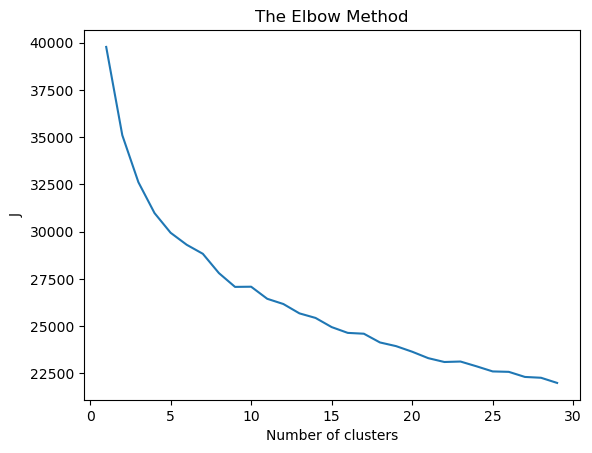

In [22]:
#decide on number of clusters using Elbow method
wcss = []
N_max = 30
for i in range(1, N_max):
    kmeans = KMeans(n_clusters=i, random_state=1, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.figure()
plt.plot(range(1, N_max),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('J')
plt.show()

In [23]:
#implement kmeans algorithm with 6 clusters based on the outcome of the elbow method
kmeans = KMeans(n_clusters=6, random_state=1, n_init="auto").fit(X)

#add column for clusters
data_cluster = X
data_cluster['Cluster']= kmeans.labels_
data_cluster.head()

,Choice,age,Gender,Education,BirthYear,LangCode,FamilSitu,NbHousehold,NbChild,NbCar,...,CostCar,TripPurpose,DestAct,NbTrajects,FreqTripHouseh,ModeToSchool,ResidChild,FreqTrainPar,FreqOtherPar,Cluster
0,0.409219,-1.450593,-0.958586,1.658364,1.450593,-1.791504,-0.630845,-0.680298,-0.675557,-0.708087,...,-0.159157,-1.205789,-0.626836,0.008635,1.128702,-0.985578,0.618219,-1.445620,-1.476360,2
1,0.409219,1.124165,1.042313,-0.120516,-1.124165,-1.791504,-0.630845,-0.680298,-0.675557,-0.708087,...,0.130976,0.959823,-0.060240,0.008635,0.092067,0.773738,0.618219,0.003713,-0.151596,4
2,0.409219,1.402517,1.042313,-0.713476,-1.402517,-1.791504,-1.325131,-1.476131,-0.675557,-0.708087,...,-0.582409,0.959823,-0.060240,-1.114855,0.092067,-0.105920,-0.941985,0.003713,-0.151596,4
3,0.409219,1.402517,1.042313,-0.713476,-1.402517,-1.791504,-1.325131,-1.476131,-0.675557,-0.708087,...,-0.677982,0.959823,1.922844,-1.114855,0.092067,-0.105920,-0.941985,0.003713,-0.151596,4
4,0.409219,-1.241828,-0.958586,2.251325,1.241828,-1.791504,-0.630845,-0.680298,-0.675557,0.676170,...,-0.283743,-1.205789,-0.910133,0.008635,0.092067,-2.744893,0.618219,1.453047,-1.476360,2


In [24]:
data_cluster.columns = [col[0] for col in data_cluster.columns]

In [25]:
#create new datasets per cluster
# Cluster 0
cluster_0 = data_cluster[data_cluster["Cluster"] == 0]
# Cluster 1
cluster_1 = data_cluster[data_cluster["Cluster"] == 1]
# Cluster 2
cluster_2 = data_cluster[data_cluster["Cluster"] == 2]
# Cluster 3
cluster_3 = data_cluster[data_cluster["Cluster"] == 3]
# Cluster 4
cluster_4 = data_cluster[data_cluster["Cluster"] == 4]
# Cluster 5
cluster_5 = data_cluster[data_cluster["Cluster"] == 5]



In [26]:

# LOGISTIC REGRESSION (BASED ON CLUSTERING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# STEP 1: PREPARE DATASET

# Copying original dataset (before scaling)
df = data.copy()

# Adding cluster labels the KMeans model
df['Cluster'] = kmeans.labels_

In [27]:
# STEP 2: CHECK TARGET VARIABLE TYPE 

print("Unique values in Choice:", df['Choice'].unique())
print("Number of classes:", df['Choice'].nunique())

# To determine whether the problem is:
# 1, Binary classification
# 2. Multi-class classification
# This affects model configuration.


Unique values in Choice: [1. 0. 2.]
Number of classes: 3


In [28]:
# STEP 3: ENCODING CATEGORICAL VARIABLES


label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le


# Encoding converts categorical variables into numeric form as logistic regression works with the numerical inputs

In [29]:

# STEP 4: DEFINING FEATURES AND TARGET

X = df.drop('Choice', axis=1)
y = df['Choice']

# 'Choice' is the dependent variable (what we predict).
# Remaining variables are independent predictors.


In [32]:

# STEP 5: TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# This ensures model is evaluated on unseen data.
# Prevents overfitting.

In [38]:

# CHECK FOR MISSING VALUES (NaNs)


# 1. TOTAL NaN COUNT IN DATASET
total_nans = df.isna().sum().sum()
print("Total NaN values in dataset:", total_nans)


# 2. NaN COUNT PER COLUMN


nan_per_column = df.isna().sum()
print("\n NaN count per column:\n")
print(nan_per_column[nan_per_column > 0])  # only columns with NaNs



# 3. EXTRACT ROWS THAT CONTAIN NaN VALUES


nan_rows = df[df.isna().any(axis=1)]

print("\n Rows containing NaN values:")
print(nan_rows.head())   # preview first few rows



# 4. COUNT OF ROWS WITH NaNs


print("\nNumber of rows containing NaNs:", nan_rows.shape[0])



Total NaN values in dataset: 573

 NaN count per column:

NbBicy               3
NbBicyChild          5
NbComp               5
NbTV                 4
Internet             2
                    ..
LifSty12             7
LifSty13             4
LifSty14             5
FreqCarPar          38
ReportedDuration    36
Length: 72, dtype: int64

 Rows containing NaN values:
          ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
1   10350120      4.0         4     116             26             34    24.8   
7   10350272      1.0         3     266             67             95    37.2   
9   10360009      4.0         1      29             12              0     6.2   
10  10360009      1.0         2      71             32              4     4.8   
11  10360009      1.0         3      90              1             38     6.2   

    CostCar  TimeCar  NbHousehold  ...  Region  distance_km  Choice  \
1      4.87       33          2.0  ...       1         45.0     1.0   
7    

In [33]:

# STEP 6: BUILDING LOGISTIC REGRESSION MODEL

model = LogisticRegression(max_iter=1000, multi_class='auto')
model.fit(X_train, y_train)

#predicting the probability of the cases

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [36]:

# STEP 7: PREDICTIONS

y_pred = model.predict(X_test)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [35]:

# STEP 8: MODEL EVALUATION (DELIVERABLES)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\n Model Accuracy:", accuracy)

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:\n", cm)

#classification report 
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined

In [ ]:

#Confusion matrix visualisation

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:

# FEATURE IMPORTANCE (COEFFICIENTS)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\n Feature Importance:")
print(coefficients)


In [ ]:

#Showing which variable strongly influences the decision
    
# Impact of cluster

cluster_effect = coefficients[coefficients['Feature'] == 'Cluster']
print("\n Impact of Cluster on Choice:")
print(cluster_effect)


In [ ]:

print(" Final observations:)
print(" Accuracy:", accuracy)
print(" Confusion Matrix:\n", cm)
print(" Classification Report displayed above")
print(" Feature Importance extracted")
print(" Cluster impact analyzed")


NameError: name 'df' is not defined

Unique values in Choice: [1. 0. 2.]
Number of classes: 3


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values